In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Load_DataSets
df  = pd.read_csv('cars24_data.csv')

In [3]:
df.head()

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28


In [4]:
df.shape

(6437, 19)

In [5]:
df.columns

Index(['name', 'make', 'model', 'city', 'year', 'fueltype', 'kilometerdriven',
       'ownernumber', 'transmission', 'bodytype', 'storename', 'isc24assured',
       'registrationcity', 'registrationstate', 'benefits', 'discountprice',
       'price', 'url', 'createdDate'],
      dtype='object')

In [6]:
#Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               6437 non-null   object
 1   make               6437 non-null   object
 2   model              6437 non-null   object
 3   city               6437 non-null   object
 4   year               6437 non-null   int64 
 5   fueltype           6437 non-null   object
 6   kilometerdriven    6437 non-null   int64 
 7   ownernumber        6437 non-null   int64 
 8   transmission       6061 non-null   object
 9   bodytype           6062 non-null   object
 10  storename          6437 non-null   object
 11  isc24assured       6437 non-null   bool  
 12  registrationcity   6437 non-null   object
 13  registrationstate  6437 non-null   object
 14  benefits           6437 non-null   int64 
 15  discountprice      6437 non-null   int64 
 16  price              6437 non-null   int64 


In [7]:
df.describe()

,year,kilometerdriven,ownernumber,benefits,discountprice,price
count,6437.000000,6437.000000,6437.000000,6437.000000,6437.000000,6.437000e+03
mean,2017.636166,41568.066335,1.235669,12079.200559,23500.592512,6.781378e+05
std,2.656825,26187.115364,0.454501,2458.162316,41579.296564,3.450395e+05
min,2008.000000,64.000000,1.000000,9688.000000,-155500.000000,1.340000e+05
25%,2016.000000,20580.000000,1.000000,9688.000000,-100.000000,4.390000e+05
50%,2018.000000,38177.000000,1.000000,12542.000000,10600.000000,5.880000e+05
75%,2020.000000,59333.000000,1.000000,13898.000000,37000.000000,8.290000e+05
max,2022.000000,455601.000000,3.000000,19407.000000,388300.000000,3.048000e+06


In [8]:
#Check_Missing_Values
df.isnull().sum()

name                   0
make                   0
model                  0
city                   0
year                   0
fueltype               0
kilometerdriven        0
ownernumber            0
transmission         376
bodytype             375
storename              0
isc24assured           0
registrationcity       0
registrationstate      0
benefits               0
discountprice          0
price                  0
url                    0
createdDate            0
dtype: int64

In [9]:
# Fill missing categorical values with mode
df['transmission'].fillna(df['transmission'].mode()[0], inplace=True)
df['bodytype'].fillna(df['bodytype'].mode()[0], inplace=True)

In [10]:
#again_Check_Missing_Values
df.isnull().sum()

name                 0
make                 0
model                0
city                 0
year                 0
fueltype             0
kilometerdriven      0
ownernumber          0
transmission         0
bodytype             0
storename            0
isc24assured         0
registrationcity     0
registrationstate    0
benefits             0
discountprice        0
price                0
url                  0
createdDate          0
dtype: int64

In [11]:
#Check_Duplicates_values
df.duplicated().sum()

np.int64(15)

In [12]:
#Remove_Duplicates_values
df.drop_duplicates(inplace=True,ignore_index=True)

In [13]:
#Again_Check_Duplicates
df.duplicated().sum()

np.int64(0)

In [14]:
# Fill all categorical columns at once
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [15]:
df['transmission'].fillna('Unknown', inplace=True)
df['bodytype'].fillna('Unknown', inplace=True)

In [16]:
#drop unwanted columns

df.drop(['url', 'name'], axis=1, inplace=True)

In [17]:
print(df.columns)

Index(['make', 'model', 'city', 'year', 'fueltype', 'kilometerdriven',
       'ownernumber', 'transmission', 'bodytype', 'storename', 'isc24assured',
       'registrationcity', 'registrationstate', 'benefits', 'discountprice',
       'price', 'createdDate'],
      dtype='object')


**VISUALIZATION**

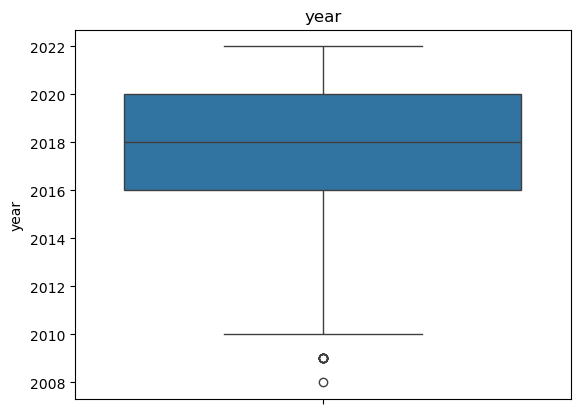

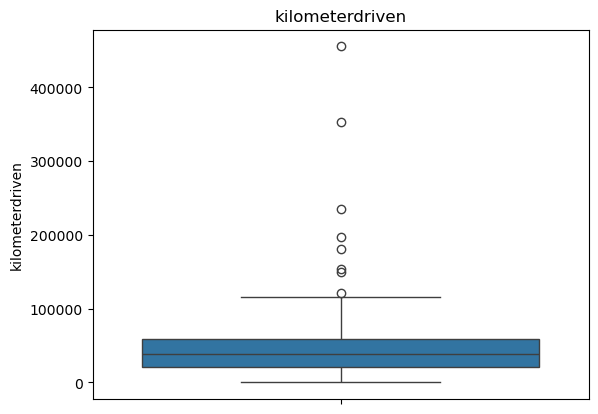

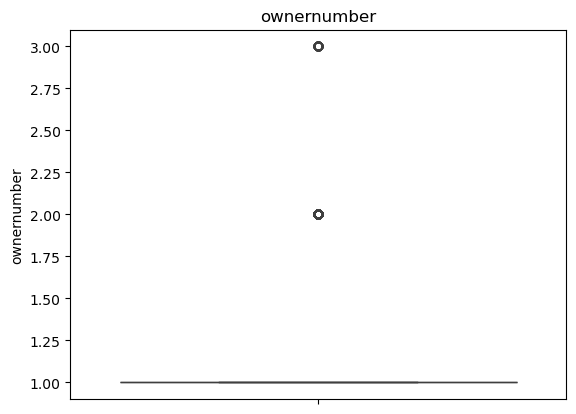

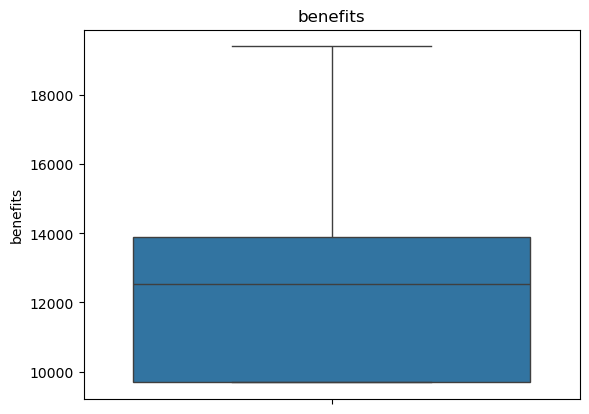

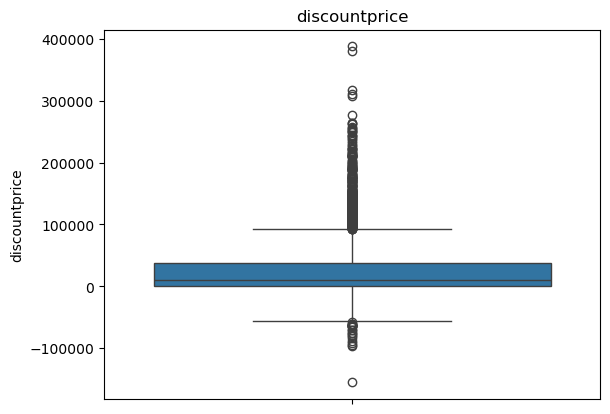

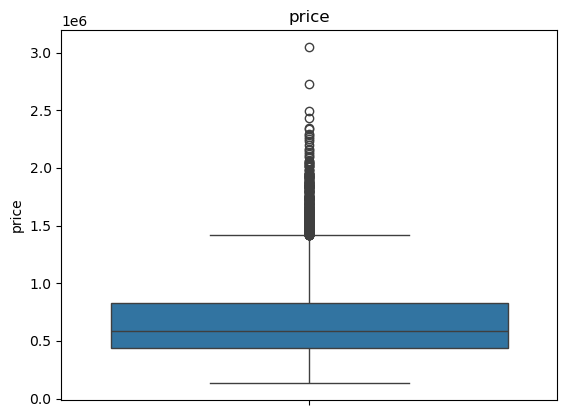

In [18]:
# only numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    sns.boxplot(data=df,y=col)
    plt.title(col)
    plt.show()

<Axes: >

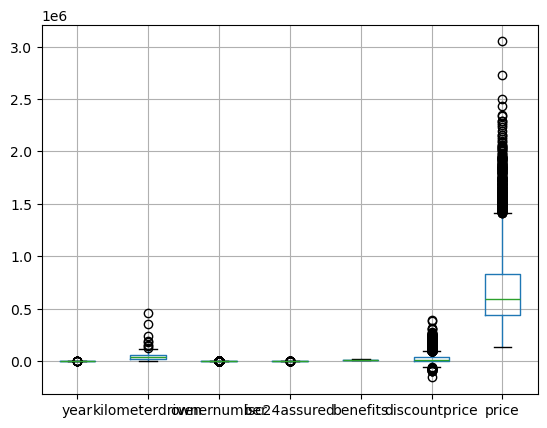

In [19]:
df.boxplot()

In [20]:
#Outlier_Capping

def outlier_capping(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_extream= Q1 - 1.5 * IQR
    upper_extream= Q3 + 1.5 * IQR

    df[column]=df[column].apply(
        lambda x : lower_extream if x<lower_extream else upper_extream if x> upper_extream else x
    )
    return df

# apply properly
for col in num_cols:
    df = outlier_capping(df,col)

<Axes: >

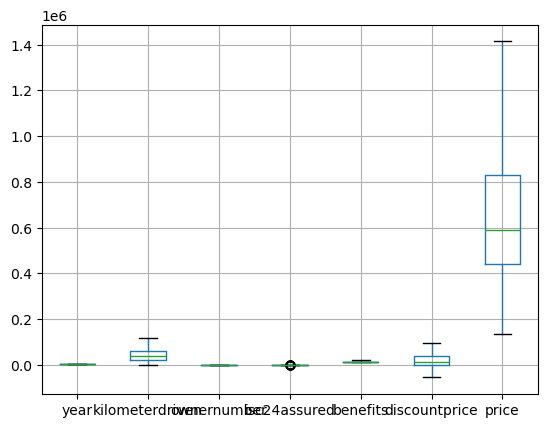

In [21]:
df.boxplot()

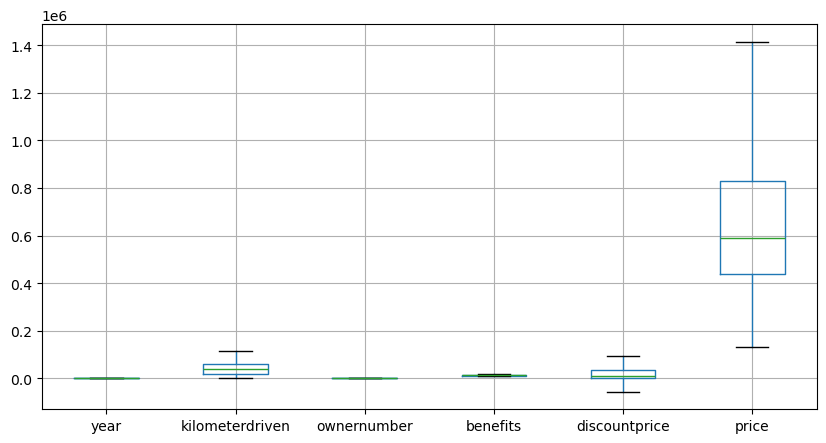

In [22]:
#Again_Outlier_Check
df[num_cols].boxplot(figsize=(10,5))
plt.show()

In [23]:
# create correlation properly
num_df = df.select_dtypes(include=['int64','float64'])

# remove constant columns
num_df = num_df.loc[:, num_df.nunique() > 1]

In [24]:
# correlation
corr = num_df.corr()

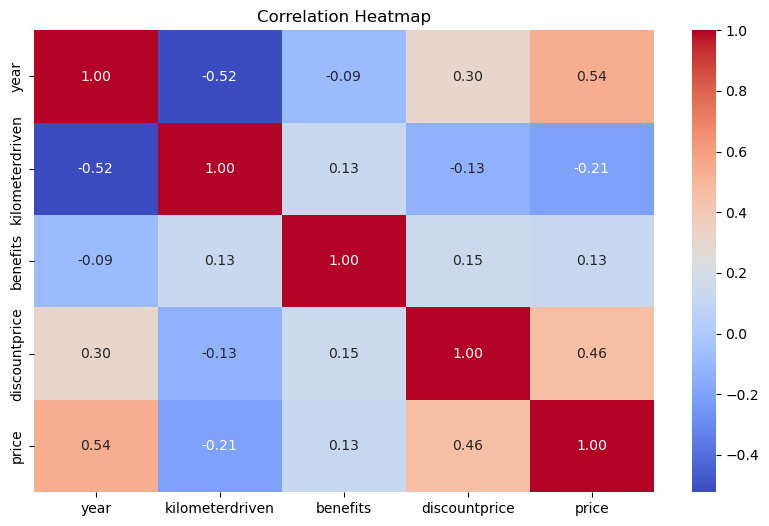

In [25]:
#correlation_Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [26]:
#Feature Selection
target = df[['price']]
features = df.drop(columns=['price'])

features.head()

,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,createdDate
0,Hyundai,Elite I20,Kochi,2017.0,Petrol,35939.0,1.0,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399.0,2022-03-24
1,Maruti,Alto 800,Mumbai,2016.0,Petrol + Cng,6180.0,1.0,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099.0,2022-11-09
2,Maruti,Dzire,Lucknow,2019.0,Petrol + Cng,46808.0,1.0,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000.0,2022-09-30
3,Kia,Seltos,Bangalore,2020.0,Diesel,26045.0,1.0,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,92837.5,2022-07-04
4,Maruti,Ertiga,Kolkata,2017.0,Petrol,53056.0,1.0,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800.0,2022-10-28


In [27]:
#Varience_Inflaction_Factor(VIF)
from  statsmodels.stats.outliers_influence import variance_inflation_factor

In [28]:
#Multicollinearity_Check_using_VIF
numerical_features = features.select_dtypes(include=[np.number])

vif = pd.DataFrame()
vif['features'] = numerical_features.columns
vif['VIF_score']= [variance_inflation_factor(numerical_features.values,i)
                   for i in range(len(numerical_features.columns))]

vif

,features,VIF_score
0,year,1.503275
1,kilometerdriven,1.392389
2,ownernumber,872103.227695
3,benefits,1.051904
4,discountprice,1.140292


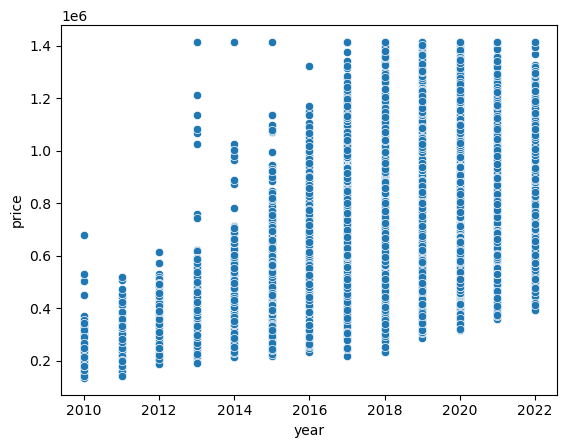

In [29]:
#Scatter_plot_Bivariate
sns.scatterplot(x=df['year'], y=df['price'])
plt.show()


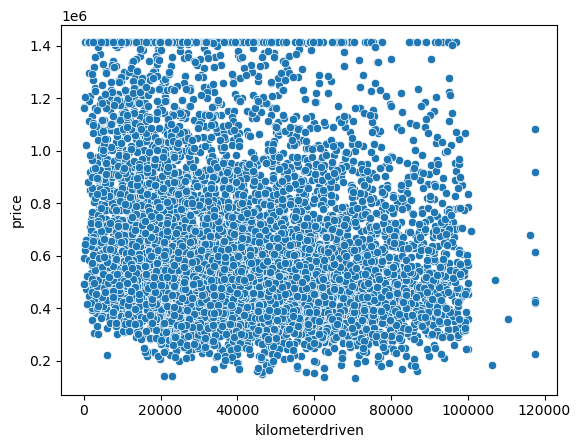

In [30]:
#Scatter_plot_Kio_Price
sns.scatterplot(x=df['kilometerdriven'], y=df['price'])
plt.show()

**MODEL BUILDING and MODEL EVALUATION**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

Encoding

In [ ]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Feature Selection and Target

In [33]:
X = df.drop("price", axis=1)
y = df["price"]

Train-Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain Size:", X_train.shape)
print("Test Size :", X_test.shape)


Train Size: (5137, 16)
Test Size : (1285, 16)


Feature Scaling

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODELS

In [36]:
# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [37]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def eval_model(name, y_train, y_train_pred, y_test, y_test_pred):
    print(f"\n=== {name} ===\n")
    
    print(f"{'Metric':<10} {'Train':<15} {'Test':<15}")
    print("-"*40)
    
    # R2
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    print(f"{'R2':<10} {train_r2:<15.4f} {test_r2:<15.4f}")
    
    # MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    print(f"{'MSE':<10} {train_mse:<15.2f} {test_mse:<15.2f}")
    
    # RMSE
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f}")

1. Linear Regression

In [38]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_lr = lr.predict(X_train)
y_test_lr = lr.predict(X_test)

eval_model("Linear Regression", y_train, y_train_lr, y_test, y_test_lr)


=== Linear Regression ===

Metric     Train           Test           
----------------------------------------
R2         0.6303          0.6571         
MSE        34070607579.04  33063407075.87 
RMSE       184582.25       181833.46      


2. K-Nearest Neighbors (KNN)

In [39]:
knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)

y_train_knn = knn.predict(X_train_scaled)
y_test_knn = knn.predict(X_test_scaled)

eval_model("K-Nearest Neighbors (KNN)", y_train, y_train_knn, y_test, y_test_knn)


=== K-Nearest Neighbors (KNN) ===

Metric     Train           Test           
----------------------------------------
R2         0.7990          0.7335         
MSE        18520731978.74  25694667835.47 
RMSE       136090.90       160295.56      


3. Support Vectore Machine (SVM)

In [40]:
svm = SVR()
svm.fit(X_train_scaled, y_train)

y_train_svm = svm.predict(X_train_scaled)
y_test_svm = svm.predict(X_test_scaled)

eval_model("Support Vector Regressor", y_train, y_train_svm, y_test, y_test_svm)


=== Support Vector Regressor ===

Metric     Train           Test           
----------------------------------------
R2         -0.0674         -0.0872        
MSE        98358203834.76  104833817999.35
RMSE       313621.12       323780.51      


4. Decision Tree Regressor

In [41]:
dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

dt.fit(X_train, y_train)

# Predictions
y_train_dt = dt.predict(X_train)
y_test_dt = dt.predict(X_test)

print("\n--- Decision Tree ---")

print("\nTrain Metrics:")
print("R2:", r2_score(y_train, y_train_dt))
print("MSE:", mean_squared_error(y_train, y_train_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_dt)))

print("\nTest Metrics:")
print("R2:", r2_score(y_test, y_test_dt))
print("MSE:", mean_squared_error(y_test, y_test_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_dt)))


--- Decision Tree ---

Train Metrics:
R2: 0.719230863394253
MSE: 25872191795.47545
RMSE: 160848.3503038668

Test Metrics:
R2: 0.7004132707549574
MSE: 28887610612.67216
RMSE: 169963.5567192925


5. Random Forest Regressor

In [42]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predictions
y_train_rf = rf.predict(X_train)
y_test_rf = rf.predict(X_test)

print("\n--- Random Forest ---")

print("\nTrain Metrics:")
print("R2:", r2_score(y_train, y_train_rf))
print("MSE:", mean_squared_error(y_train, y_train_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_rf)))

print("\nTest Metrics:")
print("R2:", r2_score(y_test, y_test_rf))
print("MSE:", mean_squared_error(y_test, y_test_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_rf)))


--- Random Forest ---

Train Metrics:
R2: 0.9721237381735517
MSE: 2568729601.9558277
RMSE: 50682.636099120056

Test Metrics:
R2: 0.9055450941944195
MSE: 9107801758.256245
RMSE: 95434.80370523242


DEEP LEARNING MODEL - ANN

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

ann.compile(optimizer='adam', loss='mse')

history = ann.fit(
    X_train_scaled, y_train,
    epochs=50,
    validation_split=0.2,
    verbose=0
)

# Predictions
y_train_ann = ann.predict(X_train_scaled).flatten()
y_test_ann = ann.predict(X_test_scaled).flatten()

eval_model("ANN", y_train, y_train_ann, y_test, y_test_ann)

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=== ANN ===

Metric     Train           Test           
----------------------------------------
R2         0.5005          0.5162         
MSE        46030249923.79  46645659274.53 
RMSE       214546.61       215976.06      


ANN- LOSS Graph

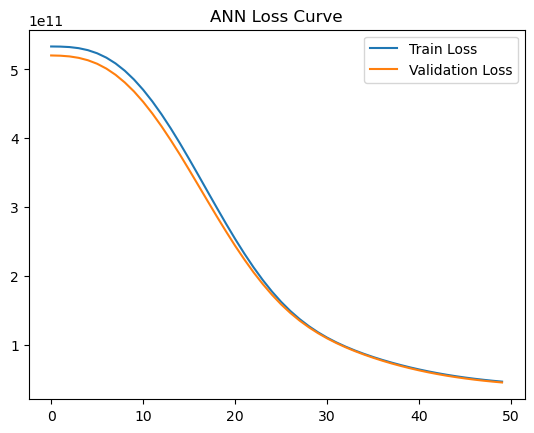

In [44]:
plt.figure()
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("ANN Loss Curve")
plt.legend()
plt.show()

ANN Performance

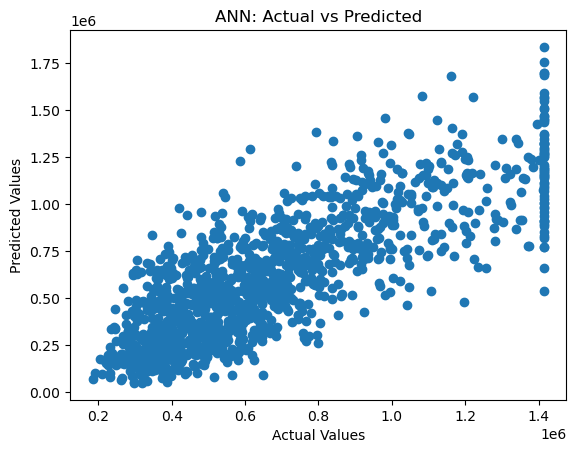

In [45]:
plt.figure()
plt.scatter(y_test, y_test_ann)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("ANN: Actual vs Predicted")

plt.show()

Comparision of all 5 Models:

In [46]:
results = [
    ["Linear Regression", r2_score(y_test, y_test_lr), np.sqrt(mean_squared_error(y_test, y_test_lr))],
    ["Decision Tree", r2_score(y_test, y_test_dt), np.sqrt(mean_squared_error(y_test, y_test_dt))],
    ["Random Forest", r2_score(y_test, y_test_rf), np.sqrt(mean_squared_error(y_test, y_test_rf))],
    ["KNN", r2_score(y_test, y_test_knn), np.sqrt(mean_squared_error(y_test, y_test_knn))],
    ["SVM", r2_score(y_test, y_test_svm), np.sqrt(mean_squared_error(y_test, y_test_svm))]
]

results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])

In [47]:
print("\n=== Model Performance ===\n")

print(f"{'Model':<20} {'R2 Score':<10} {'RMSE':<10}")
print("-"*40)

for model, r2, rmse in results:
    print(f"{model:<20} {round(r2,4):<10} {round(rmse,2):<10}")


=== Model Performance ===

Model                R2 Score   RMSE      
----------------------------------------
Linear Regression    0.6571     181833.46 
Decision Tree        0.7004     169963.56 
Random Forest        0.9055     95434.8   
KNN                  0.7335     160295.56 
SVM                  -0.0872    323780.51 


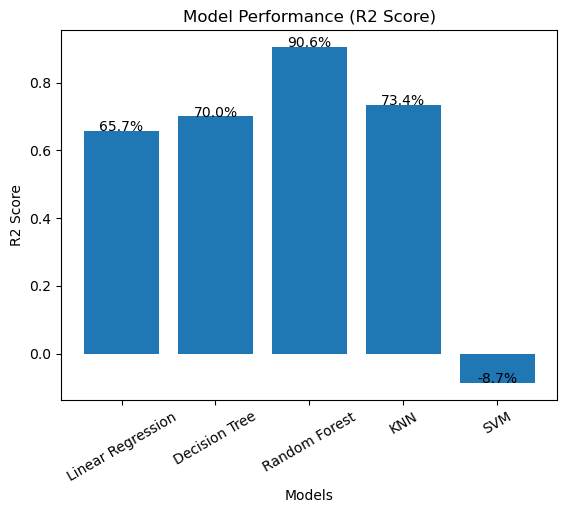

In [48]:
import matplotlib.pyplot as plt

models = [r[0] for r in results]
scores = [r[1] for r in results]

bars = plt.bar(models, scores)

for i in range(len(models)):
    plt.text(i, scores[i], str(round(scores[i]*100,1)) + "%", ha='center')

plt.title("Model Performance (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.xticks(rotation=30)
plt.show()

In [49]:
# Best based on R2 (higher is better)
best_r2_index = results_df["R2 Score"].idxmax()

# Best based on RMSE (lower is better)
best_rmse_index = results_df["RMSE"].idxmin()

print("=== Final Model Selection ===")

print("Best Model based on R2 Score :",
      results_df["Model"][best_r2_index])

print("Best Model based on RMSE     :",
      results_df["Model"][best_rmse_index])

=== Final Model Selection ===
Best Model based on R2 Score : Random Forest
Best Model based on RMSE     : Random Forest


In [50]:
if best_r2_index == best_rmse_index:
    final_model = results_df["Model"][best_r2_index]
else:
    final_model = results_df.sort_values(
        by=["R2 Score", "RMSE"],
        ascending=[False, True]
    ).iloc[0]["Model"]

print("Final Selected Best Model:", final_model)


Final Selected Best Model: Random Forest


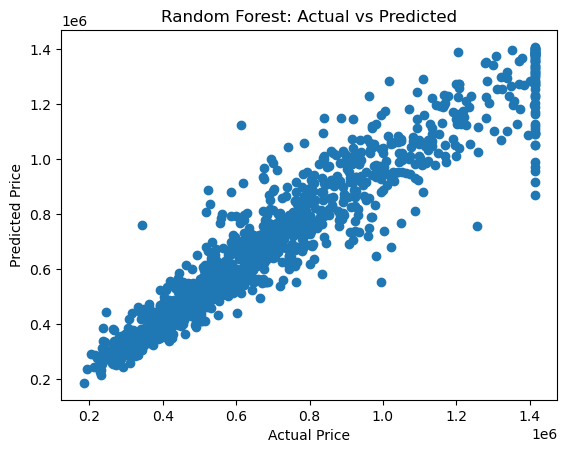

In [51]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_test_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

Feature Importance

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print("\n=== Feature Importance (Random Forest) ===\n")
print(feature_importance)


=== Feature Importance (Random Forest) ===

              Feature  Importance
8            bodytype    0.351230
3                year    0.258390
1               model    0.134104
14      discountprice    0.078943
0                make    0.054506
7        transmission    0.020812
4            fueltype    0.019065
5     kilometerdriven    0.018189
15        createdDate    0.016077
2                city    0.011481
13           benefits    0.009940
11   registrationcity    0.009735
12  registrationstate    0.009236
9           storename    0.008225
10       isc24assured    0.000067
6         ownernumber    0.000000


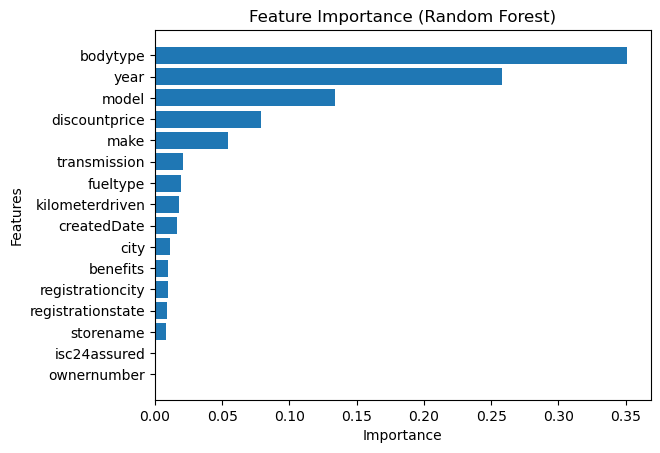

In [ ]:
plt.figure()

plt.barh(feature_importance["Feature"], feature_importance["Importance"])

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [54]:
import joblib

joblib.dump(rf, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("✅ Model trained and saved successfully!")

✅ Model trained and saved successfully!
